# 11. The Deutsch-Jozsa Algorithm

The Deutsch-Jozsa algorithm was one of the first examples of a quantum algorithm that performs a specific task exponentially faster than any possible classical algorithm. While the problem it solves is somewhat artificial, it serves as a powerful proof of concept for **Quantum Parallelism** and **Interference**.

### The Problem
Suppose we are given a "black box" function (an **Oracle**) $f: \{0,1\}^n \rightarrow \{0,1\}$. This function takes an $n$-bit string and returns either 0 or 1. We are promised that the function is either:
1.  **Constant:** It returns the same result (all 0s or all 1s) for every possible input.
2.  **Balanced:** It returns 0 for exactly half of the possible inputs and 1 for the other half.

**The Goal:** Determine if the function is Constant or Balanced by querying the Oracle.

**Classical vs. Quantum:**
* **Classically:** In the worst-case scenario, to be 100% sure, you would need to check $2^{n-1} + 1$ inputs. For a 32-bit input, that is over 2 billion queries!
* **Quantums:** The Deutsch-Jozsa algorithm solves this in exactly **one** query.

## 11.1. How it Works: The Global Phase Shift

The algorithm utilizes **Phase Kickback** to encode the function's output into the phases of a superposition.

1.  **Preparation:** We prepare $n$ input qubits in the state $|+\rangle$ and one auxiliary (ancilla) qubit in the state $|-\rangle$.
2.  **The Oracle ($U_f$):** We apply the Oracle. Classically, $f(x)$ flips the ancilla qubit. Because the ancilla is in the state $|-\rangle$, the phase kickback mechanism turns this bit-flip into a phase-flip on the input qubits:
    $$U_f |x\rangle|-\rangle = (-1)^{f(x)}|x\rangle|-\rangle$$
3.  **Interference:** After the Oracle, we apply Hadamard gates to all input qubits.
    * If the function is **Constant**, the phases are uniform, and the Hadamard gates return the qubits to the $|00...0\rangle$ state (constructive interference).
    * If the function is **Balanced**, the phases cancel each other out, resulting in a state that is orthogonal to $|00...0\rangle$ (destructive interference).

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

def dj_oracle(case, n):
    # We create a sub-circuit for the oracle
    oracle_qc = QuantumCircuit(n+1)

    if case == "balanced":
        # Example of balanced: CX from each input to the ancilla
        # This flips the ancilla for half the bitstrings
        for qubit in range(n):
            oracle_qc.cx(qubit, n)

    if case == "constant":
        # Example of constant: do nothing (returns 0 for all)
        # or flip the ancilla once (returns 1 for all)
        if np.random.randint(2) == 1:
            oracle_qc.x(n)

    oracle_gate = oracle_qc.to_gate()
    oracle_gate.name = "Oracle"
    return oracle_gate

print("Oracle generator function defined.")

Oracle generator function defined.


# 11.2. Implementation of the Algorithm

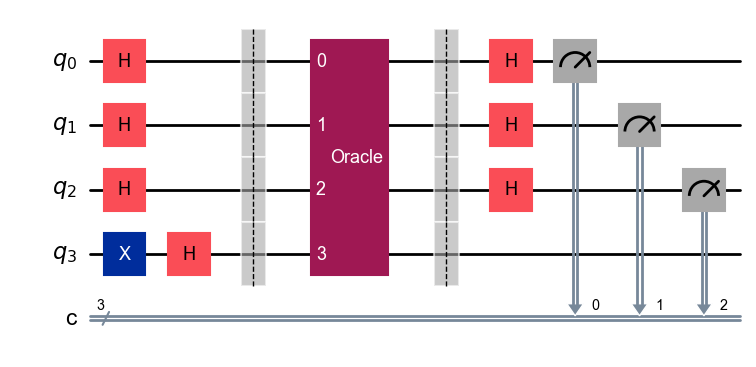

In [2]:
n = 3 # Number of input qubits
case = "balanced" # Change to "constant" to test the other case

dj_circuit = QuantumCircuit(n+1, n)

# 1. Initialize ancilla qubit to |->
dj_circuit.x(n)
dj_circuit.h(n)

# 2. Put input qubits into superposition |+>
for i in range(n):
    dj_circuit.h(i)

dj_circuit.barrier()

# 3. Apply the Oracle
dj_circuit.append(dj_oracle(case, n), range(n+1))

dj_circuit.barrier()

# 4. Apply Hadamard gates again to cause interference
for i in range(n):
    dj_circuit.h(i)

# 5. Measure the input qubits
for i in range(n):
    dj_circuit.measure(i, i)

display(dj_circuit.draw(output='mpl'))

# 11.3. Execution and Interpretation

In [3]:
simulator = AerSimulator()
transpiled_circuit = transpile(dj_circuit, simulator)
result = simulator.run(transpiled_circuit, shots=1).result()
answer = result.get_counts()

print(f"Measurement results: {answer}")

# Logic: If we measure '000', the function is Constant.
# Otherwise, it is Balanced.
if '0'*n in answer:
    print("Result: The function is CONSTANT.")
else:
    print("Result: The function is BALANCED.")

Measurement results: {'111': 1}
Result: The function is BALANCED.


## 11.4. Summary: Quantum Parallelism

The Deutsch-Jozsa algorithm illustrates the core philosophy of quantum computation. We did not "look" at the specific values of $f(x)$ for each $x$. Instead, we prepared a superposition of all possible inputs, allowed the Oracle to alter the phases of that superposition, and then used interference to extract a **global property** of the function (whether it is constant or balanced).

This "one-shot" property is why quantum computing is expected to revolutionize fields like cryptography and material science—where identifying global patterns in massive datasets is the primary bottleneck.